# Aerial → Ground synthesis pipeline

Run the cell below to **choose an aerial image** in a file dialog, then run CrossNet + GAN (same steps as `aerial_to_ground_final.py`). Figures appear **inline** in this notebook.


  Aerial → Ground Synthesis Pipeline
  Input image   : E:/anas/uni/semester 8/computer vision/project/Aerial2Ground/cvpr_subset/bingmap/bingmap/20/0000017.jpg
  CrossNet ckpt : e:\anas\uni\semester 8\computer vision\project\Aerial2Ground\outputs\ckpts_pt\crossnet_step0088830.pt
  GAN ckpt      : e:\anas\uni\semester 8\computer vision\project\Aerial2Ground\outputs\ckpts_gan\G_step0197766.pt
  Device        : cuda

[Stage 1] Loading CrossNet from:
          e:\anas\uni\semester 8\computer vision\project\Aerial2Ground\outputs\ckpts_pt\crossnet_step0088830.pt
[Stage 1] Done — semantic map generated.
[Stage 2] Loading GAN generator from:
          e:\anas\uni\semester 8\computer vision\project\Aerial2Ground\outputs\ckpts_gan\G_step0197766.pt
[Stage 2] Done — ground-view panorama synthesised.
[*] Montage saved → e:\anas\uni\semester 8\computer vision\project\Aerial2Ground\outputs\pipeline_results\0000017_full_pipeline_montage.png

[*] Result saved → e:\anas\uni\semester 8\computer vision\pr

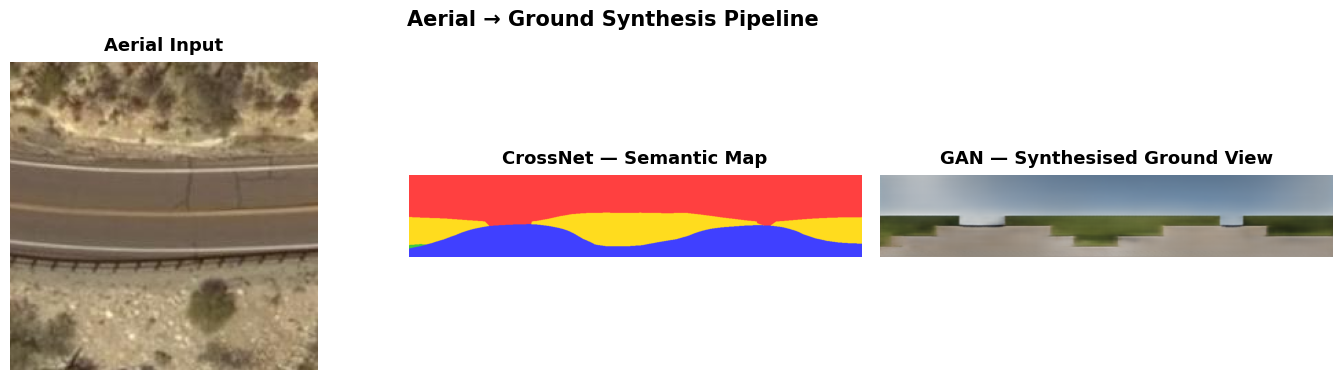

In [2]:
%matplotlib inline

import os
import sys
import tkinter as tk
from tkinter import filedialog

import torch

import aerial_to_ground_final as ag

_root = tk.Tk()
_root.withdraw()
_root.attributes("-topmost", True)
input_path = filedialog.askopenfilename(
    title="Select aerial-view image",
    filetypes=[
        ("Images", "*.png *.jpg *.jpeg *.bmp *.tif *.tiff *.webp"),
        ("All files", "*.*"),
    ],
)
_root.destroy()

if not input_path:
    sys.exit("No file selected — cancelled.")

if not os.path.isfile(input_path):
    sys.exit(f"[ERROR] Input file not found: {input_path}")

crossnet_ckpt = ag._latest_crossnet_ckpt()
gan_ckpt = ag._latest_gan_ckpt()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = ag.NUM_CLASSES
save_dir = os.path.join(ag.ROOT, "outputs", "pipeline_results")

print(f'\n{"="*60}')
print("  Aerial → Ground Synthesis Pipeline")
print(f'{"="*60}')
print(f"  Input image   : {input_path}")
print(f"  CrossNet ckpt : {crossnet_ckpt}")
print(f"  GAN ckpt      : {gan_ckpt or '(none — synthesis stage skipped)'}")
print(f"  Device        : {device}")
print(f'{"="*60}\n')

crossnet_model = ag.load_crossnet(crossnet_ckpt, num_classes, device)
aerial_tensor = ag.preprocess_aerial(input_path)
Lg, sem_pil = ag.run_crossnet(crossnet_model, aerial_tensor, device)
print("[Stage 1] Done — semantic map generated.")

G = ag.load_gan(gan_ckpt, num_classes, device)
gan_pil = ag.run_gan(G, Lg, device) if G is not None else None
if gan_pil is not None:
    print("[Stage 2] Done — ground-view panorama synthesised.")

os.makedirs(save_dir, exist_ok=True)
base = os.path.splitext(os.path.basename(input_path))[0]
sem_pil.save(os.path.join(save_dir, f"{base}_semantic_map.png"))
if gan_pil is not None:
    gan_pil.save(os.path.join(save_dir, f"{base}_ground_synthesised.png"))

montage = ag.build_display_montage(input_path, sem_pil, gan_pil)
montage_path = os.path.join(save_dir, f"{base}_full_pipeline_montage.png")
montage.save(montage_path)
print(f"[*] Montage saved → {montage_path}")

ag.display_results(input_path, sem_pil, gan_pil, save_dir)